In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features.process_features import *
pd.set_option('display.max_columns', None)

# 0. Load dataframe

We start by removing `SP` (was processed and is not used anymore), `winnerOr2ndName`, `winnerOr2ndId` (those twoa re not used later)

In [2]:
# Specify the columns you want to remove here
cols_to_remove = ["SP","winnerOr2ndName","winnerOr2ndId"] 
all_cols = ['SP', 'resultPosition', 
               'resultBtnDistance', 'resultSectionalTime',
               'resultComment', 'resultRunTime', 
               'resultDogWeight', 'winnerOr2ndName',
               'winnerOr2ndId', 'resultAdjustedTime', 
               'trapNumber', 'raceTime',
               'raceDate', 'raceId', 
               'raceType', 'raceClass', 
               'raceDistance','raceGoing', 
               'raceWinTime', 'meetingId', 
               'trackName', 'dogId',
               'numeratorSP', 'denominatorSP', 
               'commentScore','resultSectionalTime_missing']
cols_to_use = [col for col in all_cols if col not in cols_to_remove]

model_df = pd.read_csv("../data/intermediate/04_dog_infos_cleaned.csv", usecols=cols_to_use)

In [3]:
model_df.head()

,resultPosition,resultBtnDistance,resultSectionalTime,resultComment,resultRunTime,resultDogWeight,resultAdjustedTime,trapNumber,raceTime,raceDate,raceId,raceType,raceClass,raceDistance,raceGoing,raceWinTime,meetingId,trackName,dogId,numeratorSP,denominatorSP,commentScore,resultSectionalTime_missing
0,4.0,2.00,4.46,"Middle,EveryChance",28.73,34.1,28.73,5,21:18:00,2022-03-24,826826,Flat,A1,480.0,0.0,28.24,383435,Monmore,100211,5.0,4.000000,-1.0,0
1,3.0,1.75,4.46,"CrdStt,Middle,RanOn",28.46,33.9,28.36,3,20:43:00,2022-03-12,823113,Flat,OR,480.0,-10.0,28.06,382921,Monmore,100211,7.0,1.000000,0.0,0
2,3.0,1.00,4.53,"Mid,FcdTCk&Crd1",28.72,33.9,28.72,3,16:48:00,2022-03-04,821053,Flat,A1,480.0,0.0,28.58,382798,Monmore,100211,11.0,1.675319,-1.0,0
3,6.0,10.00,4.45,"Crd1,Chl&Crd&FellRunIn",28.98,34.1,28.85,4,18:17:00,2022-01-29,811419,Flat,A1,480.0,0.0,28.51,381677,Monmore,100211,1.0,1.000000,0.0,0
4,2.0,10.00,4.45,"CrdStt,EP,Mid,RanOn",28.69,34.5,28.49,5,16:08:00,2022-01-21,809513,Flat,A1,480.0,-20.0,28.63,381477,Monmore,100211,11.0,1.675319,1.0,0


# 1. Feature Engineering

## 1.1 Split A class/other race infos

We seperate race class A from other and attirbute relevance based on the class type. The idea is to compare what is comparable and sprint races are a different kind of races. 


In the final model, we will feed to a lstm only the A class race and the others will be used for statistics. The model will be trained to only predict A class races

In [4]:
CLASS_CONFIG = {

    # ── A GRADES: directly in LSTM sequence ──────────────────────
    # Numeric grade = inverse of number (A1 = best = highest level)
    'A1':  {'group': 'graded_a', 'relevance': 1.0, 'quality': 13, 'in_lstm': True},
    'A2':  {'group': 'graded_a', 'relevance': 1.0, 'quality': 12, 'in_lstm': True},
    'A3':  {'group': 'graded_a', 'relevance': 1.0, 'quality': 11, 'in_lstm': True},
    'A4':  {'group': 'graded_a', 'relevance': 1.0, 'quality': 10, 'in_lstm': True},
    'A5':  {'group': 'graded_a', 'relevance': 1.0, 'quality':  9, 'in_lstm': True},
    'A6':  {'group': 'graded_a', 'relevance': 1.0, 'quality':  8, 'in_lstm': True},
    'A7':  {'group': 'graded_a', 'relevance': 1.0, 'quality':  7, 'in_lstm': True},
    'A8':  {'group': 'graded_a', 'relevance': 1.0, 'quality':  6, 'in_lstm': True},
    'A9':  {'group': 'graded_a', 'relevance': 1.0, 'quality':  5, 'in_lstm': True},
    'A10': {'group': 'graded_a', 'relevance': 1.0, 'quality':  4, 'in_lstm': True},
    'A11': {'group': 'graded_a', 'relevance': 1.0, 'quality':  3, 'in_lstm': True},
    'A12': {'group': 'graded_a', 'relevance': 1.0, 'quality':  2, 'in_lstm': True},
    'A15': {'group': 'graded_a', 'relevance': 1.0, 'quality':  1, 'in_lstm': True},

    # ── OPEN RACES: static features, quality above A1 ───────────
    'OR':  {'group': 'open', 'relevance': 0.9, 'quality': 16, 'in_lstm': False},
    'OR1': {'group': 'open', 'relevance': 0.9, 'quality': 15, 'in_lstm': False},
    'OR2': {'group': 'open', 'relevance': 0.85,'quality': 14, 'in_lstm': False},
    'OR3': {'group': 'open', 'relevance': 0.80,'quality': 13, 'in_lstm': False},
    'GR':  {'group': 'open', 'relevance': 0.9, 'quality': 15, 'in_lstm': False},
    'E1':  {'group': 'open', 'relevance': 0.85,'quality': 14, 'in_lstm': False},
    'E2':  {'group': 'open', 'relevance': 0.80,'quality': 13, 'in_lstm': False},
    'E3':  {'group': 'open', 'relevance': 0.75,'quality': 12, 'in_lstm': False},

    # ── B GRADES: static only, sex-restricted ───────────────────
    'B1':  {'group': 'graded_b', 'relevance': 0.75,'quality': 10, 'in_lstm': False},
    'B2':  {'group': 'graded_b', 'relevance': 0.75,'quality':  9, 'in_lstm': False},
    'B3':  {'group': 'graded_b', 'relevance': 0.75,'quality':  8, 'in_lstm': False},
    'B4':  {'group': 'graded_b', 'relevance': 0.75,'quality':  7, 'in_lstm': False},
    'B5':  {'group': 'graded_b', 'relevance': 0.75,'quality':  6, 'in_lstm': False},
    'B6':  {'group': 'graded_b', 'relevance': 0.75,'quality':  5, 'in_lstm': False},
    'B7':  {'group': 'graded_b', 'relevance': 0.75,'quality':  4, 'in_lstm': False},
    'B8':  {'group': 'graded_b', 'relevance': 0.75,'quality':  3, 'in_lstm': False},
    'B9':  {'group': 'graded_b', 'relevance': 0.75,'quality':  2, 'in_lstm': False},
    'B15': {'group': 'graded_b', 'relevance': 0.75,'quality':  1, 'in_lstm': False},

    # ── S GRADES: sprint — static only, incompatible times ──────
    'S1':  {'group': 'sprint', 'relevance': 0.55,'quality':  8, 'in_lstm': False},
    'S2':  {'group': 'sprint', 'relevance': 0.55,'quality':  7, 'in_lstm': False},
    'S3':  {'group': 'sprint', 'relevance': 0.55,'quality':  6, 'in_lstm': False},
    'S4':  {'group': 'sprint', 'relevance': 0.55,'quality':  5, 'in_lstm': False},
    'S5':  {'group': 'sprint', 'relevance': 0.55,'quality':  4, 'in_lstm': False},
    'S6':  {'group': 'sprint', 'relevance': 0.55,'quality':  3, 'in_lstm': False},
    'S7':  {'group': 'sprint', 'relevance': 0.55,'quality':  2, 'in_lstm': False},
    'S8':  {'group': 'sprint', 'relevance': 0.55,'quality':  1, 'in_lstm': False},
    'S15': {'group': 'sprint', 'relevance': 0.55,'quality':  1, 'in_lstm': False},

    # ── D GRADES: distance — static only, incompatible times ────
    'D1':  {'group': 'distance', 'relevance': 0.45,'quality':  5, 'in_lstm': False},
    'D2':  {'group': 'distance', 'relevance': 0.45,'quality':  4, 'in_lstm': False},
    'D3':  {'group': 'distance', 'relevance': 0.45,'quality':  3, 'in_lstm': False},
    'D4':  {'group': 'distance', 'relevance': 0.45,'quality':  2, 'in_lstm': False},
    'D5':  {'group': 'distance', 'relevance': 0.45,'quality':  1, 'in_lstm': False},

    # ── M GRADES: middle distance — static only ──────────────────
    'M1':  {'group': 'middle', 'relevance': 0.60,'quality':  5, 'in_lstm': False},
    'M2':  {'group': 'middle', 'relevance': 0.60,'quality':  4, 'in_lstm': False},
    'M3':  {'group': 'middle', 'relevance': 0.60,'quality':  3, 'in_lstm': False},
    'M4':  {'group': 'middle', 'relevance': 0.60,'quality':  2, 'in_lstm': False},
    'M5':  {'group': 'middle', 'relevance': 0.60,'quality':  1, 'in_lstm': False},

    # ── P GRADES: puppy/juvenile — static only ───────────────────
    'P1':  {'group': 'puppy', 'relevance': 0.40,'quality':  9, 'in_lstm': False},
    'P2':  {'group': 'puppy', 'relevance': 0.40,'quality':  8, 'in_lstm': False},
    'P3':  {'group': 'puppy', 'relevance': 0.40,'quality':  7, 'in_lstm': False},
    'P4':  {'group': 'puppy', 'relevance': 0.40,'quality':  6, 'in_lstm': False},
    'P5':  {'group': 'puppy', 'relevance': 0.40,'quality':  5, 'in_lstm': False},
    'P6':  {'group': 'puppy', 'relevance': 0.40,'quality':  4, 'in_lstm': False},
    'P7':  {'group': 'puppy', 'relevance': 0.40,'quality':  3, 'in_lstm': False},
    'P8':  {'group': 'puppy', 'relevance': 0.40,'quality':  2, 'in_lstm': False},
    'P9':  {'group': 'puppy', 'relevance': 0.40,'quality':  1, 'in_lstm': False},
    'P10': {'group': 'puppy', 'relevance': 0.40,'quality':  1, 'in_lstm': False},

    # ── HURDLES: exclude entirely from performance features ──────
    'H1':  {'group': 'hurdles', 'relevance': 0.05,'quality': 0, 'in_lstm': False},
    'H2':  {'group': 'hurdles', 'relevance': 0.05,'quality': 0, 'in_lstm': False},
    'H3':  {'group': 'hurdles', 'relevance': 0.05,'quality': 0, 'in_lstm': False},
    'H4':  {'group': 'hurdles', 'relevance': 0.05,'quality': 0, 'in_lstm': False},
    'HS1': {'group': 'hurdles', 'relevance': 0.05,'quality': 0, 'in_lstm': False},
    'HS2': {'group': 'hurdles', 'relevance': 0.05,'quality': 0, 'in_lstm': False},
    'HD2': {'group': 'hurdles', 'relevance': 0.05,'quality': 0, 'in_lstm': False},
    'HP':  {'group': 'hurdles', 'relevance': 0.05,'quality': 0, 'in_lstm': False},

    # ── TRIALS / SPECIAL: flag only ──────────────────────────────
    'IT':  {'group': 'trial', 'relevance': 0.05,'quality': 0, 'in_lstm': False},
    'IV':  {'group': 'trial', 'relevance': 0.05,'quality': 0, 'in_lstm': False},
    'KS':  {'group': 'trial', 'relevance': 0.05,'quality': 0, 'in_lstm': False},
    'ks':  {'group': 'trial', 'relevance': 0.05,'quality': 0, 'in_lstm': False},
}

FALLBACK = {'group': 'unknown', 'relevance': 0.10, 'quality': 0, 'in_lstm': False}

def get_class_config(race_class):
    if pd.isna(race_class):
        return FALLBACK
    return CLASS_CONFIG.get(str(race_class).strip(), FALLBACK)

In [5]:
def process_dog_history(dog_history):
    """
    Route each race in history to the right processing stream.
    """
    
    h = dog_history.copy()
    h['classGroup']   = h['raceClass'].apply(lambda c: get_class_config(c)['group'])
    h['relevance']     = h['raceClass'].apply(lambda c: get_class_config(c)['relevance'])
    h['qualityLevel'] = h['raceClass'].apply(lambda c: get_class_config(c)['quality'])
    h['inLSTM']       = h['raceClass'].apply(lambda c: get_class_config(c)['in_lstm'])

    # ── Stream 1: LSTM sequence ───────────────────────────────────
    # Only A-grade races — coherent times, directly comparable
    lstm_seq = (
        h[h['in_lstm']]
        .sort_values('raceDate', ascending=False)
        .head(10)
    )

    # ── Stream 2: Static performance features ─────────────────────
    # All classes weighted by relevance, excluding hurdles/trials
    perf_history = h[h['relevance'] > 0.10]

    # ── Stream 3: Binary flags ────────────────────────────────────
    # Signals derived from presence/absence of specific class types
    flags = _compute_flags(h)

    return lstm_seq, perf_history, flags


def _compute_flags(h):
    today = h['raceDate'].max()

    return {
        # Class trajectory: where has the dog been racing recently?
        'class_trajectory_5r': (
            h.sort_values('raceDate', ascending=False)
            .head(5)['quality_level'].mean() - 9.0  # 9 ≈ mid A-grade
        ),

        # Immediate class drop/rise into target A race
        'last_race_quality': (
            h.sort_values('raceDate', ascending=False)
            .iloc[0]['quality_level'] if len(h) > 0 else 9
        ),

        # Has ever competed in open/featured race
        'has_open_race_exp': int(
            h['class_group'].isin(['open']).any()
        ),
        'won_open_race': int(
            ((h['class_group'] == 'open') & (h['resultPosition'] == 1)).any()
        ),

        # Sprint experience — proxy for early pace ability
        'sprint_win_rate': (
            h[h['class_group'] == 'sprint']['resultPosition'].mean()
            if (h['class_group'] == 'sprint').sum() >= 3 else np.nan
        ),

        # Trial in last 14 days — trainer preparation signal
        'had_recent_trial': int((
            (h['class_group'].isin(['trial'])) &
            (h['raceDate'] >= today - pd.Timedelta(days=14))
        ).any()),

        # Hurdles contamination — how much of history is useless
        'hurdles_history_pct': (
            (h['class_group'] == 'hurdles').mean()
        ),

        # History quality — average relevance of past races
        'history_comparability': h['relevance'].mean(),

        # KS/ks — normalise case first, then flag
        # These appear to be a specific competition type
        'has_ks_race': int(
            h['race_class'].str.upper().eq('KS').any()
            if h['race_class'].notna().any() else False
        ),
    }

In [6]:
model_df['classGroup']   = model_df['raceClass'].apply(lambda c: get_class_config(c)['group'])
model_df['relevance']     = model_df['raceClass'].apply(lambda c: get_class_config(c)['relevance'])
model_df['qualityLevel'] = model_df['raceClass'].apply(lambda c: get_class_config(c)['quality'])
model_df['inLSTM']       = model_df['raceClass'].apply(lambda c: get_class_config(c)['in_lstm'])

In [7]:
#################### APPLY HERE _compute_flags TO DOG_INFOS ####################
model_df["raceDate"] = pd.to_datetime(model_df["raceDate"], errors="coerce")
model_df["raceClass"] = model_df["raceClass"].astype("string").str.strip().str.upper()

flag_feature_names = [
    "class_trajectory_5r",
    "last_race_quality",
    "has_open_race_exp",
    "won_open_race",
    "had_recent_trial",
    "hurdles_history_pct",
    "history_comparability",
    "has_ks_race",
]

def _empty_history_flags():
    return {
        "class_trajectory_5r": np.nan,
        "last_race_quality": 9,
        "has_open_race_exp": 0,
        "won_open_race": 0,
        "had_recent_trial": 0,
        "hurdles_history_pct": 0.0,
        "history_comparability": np.nan,
        "has_ks_race": 0,
    }

def _apply_compute_flags_to_group(dog_history):
    dog_history = dog_history.sort_values(["raceDate", "raceId"]).copy()

    configs = dog_history["raceClass"].apply(get_class_config)
    dog_history["class_group"] = configs.apply(lambda cfg: cfg["group"])
    dog_history["relevance"] = configs.apply(lambda cfg: cfg["relevance"])
    dog_history["quality_level"] = configs.apply(lambda cfg: cfg["quality"])
    dog_history["race_class"] = dog_history["raceClass"]

    history_flags = []
    recent_qualities = []
    sprint_positions = []
    trial_dates = []

    total_past_races = 0
    hurdles_count = 0
    relevance_sum = 0.0
    has_open_race_exp = False
    won_open_race = False
    has_ks_race = False
    last_race_quality = 9

    for row in dog_history.itertuples():
        if total_past_races == 0:
            history_flags.append(_empty_history_flags())
        else:
            current_date = row.raceDate
            if pd.isna(current_date):
                had_recent_trial = 0
            else:
                cutoff_date = current_date - pd.Timedelta(days=14)
                trial_dates = [d for d in trial_dates if d >= cutoff_date]
                had_recent_trial = int(len(trial_dates) > 0)

            history_flags.append({
                "class_trajectory_5r": np.mean(recent_qualities) - 9.0 if recent_qualities else np.nan,
                "last_race_quality": last_race_quality,
                "has_open_race_exp": int(has_open_race_exp),
                "won_open_race": int(won_open_race),
                "had_recent_trial": had_recent_trial,
                "hurdles_history_pct": hurdles_count / total_past_races,
                "history_comparability": relevance_sum / total_past_races,
                "has_ks_race": int(has_ks_race),
            })

        total_past_races += 1
        relevance_sum += row.relevance
        last_race_quality = row.quality_level

        recent_qualities.append(row.quality_level)
        if len(recent_qualities) > 5:
            recent_qualities.pop(0)

        if row.class_group == "open":
            has_open_race_exp = True
            won_open_race = won_open_race or (row.resultPosition == 1)

        if row.class_group == "sprint" and pd.notna(row.resultPosition):
            sprint_positions.append(row.resultPosition)

        if row.class_group == "trial" and pd.notna(row.raceDate):
            trial_dates.append(row.raceDate)

        if row.class_group == "hurdles":
            hurdles_count += 1

        race_class_value = str(row.race_class).upper() if pd.notna(row.race_class) else ""
        if race_class_value == "KS":
            has_ks_race = True

    return pd.DataFrame(history_flags, index=dog_history.index)[flag_feature_names]

dog_history_flags = (
    model_df.sort_values(["dogId", "raceDate", "raceId"])
    .groupby("dogId", group_keys=False)
    .apply(_apply_compute_flags_to_group)
    .reindex(model_df.index)
)

model_df = pd.concat([model_df, dog_history_flags], axis=1)
model_df[flag_feature_names].head()
################################################################################

,class_trajectory_5r,last_race_quality,has_open_race_exp,won_open_race,had_recent_trial,hurdles_history_pct,history_comparability,has_ks_race
0,5.2,16,1,1,0,0.0,0.920000,0
1,5.2,13,1,1,0,0.0,0.921429,0
2,5.8,13,1,1,0,0.0,0.915385,0
3,6.4,13,1,1,0,0.0,0.908333,0
4,7.0,16,1,1,0,0.0,0.900000,0


## 1.2 Race date features

We will use the race date to produce:

- `raceYear`: the year of the race

- `raceMonth`: month of the race

- `raceDayOfWeek`: day of the race week

- `raceDayOfYear`: day of the whole year

- `timeSinceLastRace`: time span between each races

This will give the model context on the time influence of the race.

In [8]:
model_df["raceDate"] = pd.to_datetime(model_df["raceDate"], errors="coerce")
model_df["raceYear"] = model_df["raceDate"].dt.year
model_df["raceMonth"] = model_df["raceDate"].dt.month
model_df["raceDayOfWeek"] = model_df["raceDate"].dt.dayofweek
model_df["raceDayOfYear"] = model_df["raceDate"].dt.dayofyear

model_df = time_since_last_race(model_df)

## 1.3 SP features

- `spDecimal`: the division of numerator and denominator of SP

- `impliedProb`: implied market probability

In [9]:
model_df["spDecimal"] = 1 + model_df["numeratorSP"].fillna(0) / model_df["denominatorSP"].replace(0, np.nan)
model_df["impliedProb"] = 1 / model_df["spDecimal"]

## 1.4 Time based features

We compute from all the time features the delta and speed features:

- `deltaWinTime`: difference between the winner and the dog result time

- `adjustedDeltaWinTime`: adjusted difference between the winner and the dog result time

- `runSpeed`: result time divided by the race distance

- `adjustedRunSpeed`: adjusted result time divided by the race distance

In [10]:
model_df["deltaWinTime"] = model_df["resultRunTime"] - model_df["raceWinTime"]
model_df["adjustedDeltaWinTime"] = model_df["resultAdjustedTime"] - model_df["raceWinTime"]
model_df["runSpeed"] = model_df["raceDistance"] / model_df["resultRunTime"].replace(0, np.nan)
model_df["adjustedRunSpeed"] = model_df["raceDistance"] / model_df["resultAdjustedTime"].replace(0, np.nan)

## 1.5 Race class features

In [11]:
model_df["raceClassFamily"] = model_df["raceClass"].str.extract(r"([A-Za-z]+)", expand=False).fillna("Unknown")
model_df["raceClassGrade"] = pd.to_numeric(
    model_df["raceClass"].str.extract(r"(\d+)", expand=False),
    errors="coerce",
)

## 1.6 Result comments features 

In [12]:
comment_text = model_df["resultComment"].fillna("").str.lower()
model_df["commentLength"] = comment_text.str.len()
model_df["commentHasClear"] = comment_text.str.contains("clear|clrrun")
model_df["commentHasCrowded"] = comment_text.str.contains("crowd|crd")
model_df["commentHasBump"] = comment_text.str.contains("bmp|baulk")
model_df["commentHasEarlyPace"] = comment_text.str.contains("qaw|ep|led")
model_df["commentHasWide"] = comment_text.str.contains("wide|mid")

## 1.7 Others

`isBeginner` is a flag to tell wether it is a dog's first race, making it a beginner. 

In [13]:
model_df["isBeginner"] = model_df["daysSinceLastRace"].isna().astype(int)

## 1.8 Early race position features

`earlyPosition`: selecting all the sectional time from all dogs in the race, we can determine the early position of the dogs 

`deltaEarlyFinalPosition`: from the early dog position, we can determine the difference between its early position and its final position

In [14]:
early_pos_race_dog(model_df)

## 1.9 Trap bias on result position

`trapBiasResultPosition` is the median result position based on **track**, **distance** and **trap**.

In [15]:
# Compute the result position biased by the trap
stats = model_df.groupby(
    ['trackName','raceDistance',"trapNumber"]
)["resultPosition"].median().reset_index()

stats = stats.rename(columns={"resultPosition": "trapBiasResultPosition"})

model_df = model_df.merge(
    stats,
    on=['trackName', 'raceDistance', 'trapNumber'],
    how='left'
)

Save `stats` to have the result position bias to add to the race header:

In [ ]:
stats.to_csv("../data/processed/05_trap_bias_stats.csv", index=False)

# 2. Final cleaning

## 2.1 Missing values check

In [16]:
cols_to_remove = ["resultComment","raceTime","raceDate","raceType",]
cols_subset = [col for col in model_df.columns if col not in cols_to_remove]

In [17]:
model_df.head()

,resultPosition,resultBtnDistance,resultSectionalTime,resultComment,resultRunTime,resultDogWeight,resultAdjustedTime,trapNumber,raceTime,raceDate,raceId,raceType,raceClass,raceDistance,raceGoing,raceWinTime,meetingId,trackName,dogId,numeratorSP,denominatorSP,commentScore,resultSectionalTime_missing,classGroup,relevance,qualityLevel,inLSTM,class_trajectory_5r,last_race_quality,has_open_race_exp,won_open_race,had_recent_trial,hurdles_history_pct,history_comparability,has_ks_race,raceYear,raceMonth,raceDayOfWeek,raceDayOfYear,daysSinceLastRace,spDecimal,impliedProb,deltaWinTime,adjustedDeltaWinTime,runSpeed,adjustedRunSpeed,raceClassFamily,raceClassGrade,commentLength,commentHasClear,commentHasCrowded,commentHasBump,commentHasEarlyPace,commentHasWide,isBeginner,earlyPosition,deltaEarlyFinalPosition,trapBiasResultPosition
0,3.0,4.75,4.52,"EP,Crd1",28.44,27.5,28.54,1,20:53:00,2016-03-22,203015,Flat,A6,450.0,10.0,27.79,310979,Poole,744,9.0,2.0,1.0,0,graded_a,1.0,8,True,NaN,9,0,0,0,0.0,NaN,0,2016,3,1,82,NaN,5.5,0.181818,0.65,0.75,15.822785,15.767344,A,6,7,False,True,False,True,False,1,2,-1.0,3.0
1,1.0,0.00,4.46,"EP,Led 1/2",27.57,27.3,27.67,1,18:04:00,2016-03-27,204415,Flat,A7,450.0,10.0,27.57,311068,Poole,744,2.0,1.0,3.5,0,graded_a,1.0,7,True,-1.000000,8,0,0,0,0.0,1.0,0,2016,3,6,87,5.0,3.0,0.333333,0.00,0.10,16.322089,16.263101,A,7,10,False,False,False,True,False,0,3,2.0,3.0
2,4.0,1.25,4.62,SAw,27.97,27.4,27.97,2,20:02:00,2016-04-03,206485,Flat,A6,450.0,0.0,27.52,311291,Poole,744,2.0,1.0,0.0,0,graded_a,1.0,8,True,-1.500000,7,0,0,0,0.0,1.0,0,2016,4,6,94,7.0,3.0,0.333333,0.45,0.45,16.088666,16.088666,A,6,3,False,False,False,False,False,0,5,1.0,3.0
3,4.0,1.75,4.56,"SAw,Crd3",28.07,28.1,28.07,2,20:52:00,2016-04-16,210756,Flat,A6,450.0,0.0,27.35,311861,Poole,744,3.0,1.0,-0.5,0,graded_a,1.0,8,True,-1.333333,8,0,0,0,0.0,1.0,0,2016,4,5,107,13.0,4.0,0.250000,0.72,0.72,16.031350,16.031350,A,6,8,False,True,False,False,False,0,6,2.0,3.0
4,1.0,0.00,4.54,"SAw,LedNearLine",27.86,27.8,27.86,1,22:22:00,2016-04-23,213059,Flat,A6,450.0,0.0,27.86,312112,Poole,744,3.0,1.0,0.0,0,graded_a,1.0,8,True,-1.250000,8,0,0,0,0.0,1.0,0,2016,4,5,114,7.0,4.0,0.250000,0.00,0.00,16.152190,16.152190,A,6,15,False,False,False,True,False,0,6,5.0,3.0


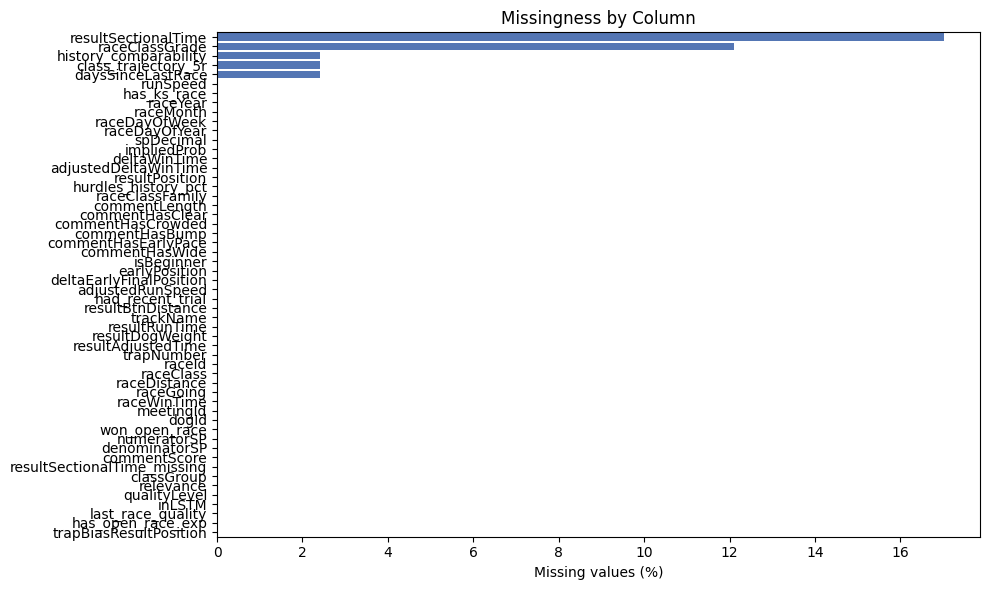

,missing_pct
resultSectionalTime,17.015621
raceClassGrade,12.098774
history_comparability,2.419288
class_trajectory_5r,2.419288
daysSinceLastRace,2.419288
runSpeed,0.000000
has_ks_race,0.000000
raceYear,0.000000
raceMonth,0.000000
raceDayOfWeek,0.000000


In [18]:
missingness = (
    model_df[cols_subset].isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .to_frame()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=missingness.reset_index(), x="missing_pct", y="index", color="#4472c4")
plt.title("Missingness by Column")
plt.xlabel("Missing values (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

missingness

In [19]:
model_df.describe()

,resultPosition,resultBtnDistance,resultSectionalTime,resultRunTime,resultDogWeight,resultAdjustedTime,trapNumber,raceDate,raceId,raceDistance,raceGoing,raceWinTime,meetingId,dogId,numeratorSP,denominatorSP,commentScore,resultSectionalTime_missing,relevance,qualityLevel,class_trajectory_5r,last_race_quality,has_open_race_exp,won_open_race,had_recent_trial,hurdles_history_pct,history_comparability,has_ks_race,raceYear,raceMonth,raceDayOfWeek,raceDayOfYear,daysSinceLastRace,spDecimal,impliedProb,deltaWinTime,adjustedDeltaWinTime,runSpeed,adjustedRunSpeed,raceClassGrade,commentLength,isBeginner,earlyPosition,deltaEarlyFinalPosition,trapBiasResultPosition
count,3.383103e+06,3.383103e+06,2.807447e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3383103,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.301256e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.301256e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.301256e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,2973789.0,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06
mean,3.434856e+00,2.979896e+00,5.030550e+00,2.869812e+01,2.996382e+01,2.868684e+01,3.478492e+00,2019-06-25 13:08:34.652376,5.369932e+05,4.455550e+02,-5.365590e-01,2.834907e+01,3.511598e+05,5.095508e+05,6.625621e+00,1.675319e+00,1.148522e-01,1.701562e-01,8.568664e-01,8.266537e+00,-7.138994e-01,8.297823e+00,2.880229e-01,1.233069e-01,5.234839e-03,4.432869e-02,8.696299e-01,4.121069e-03,2.018989e+03,6.438085e+00,3.231251e+00,1.805033e+02,1.158962e+01,5.735674e+00,2.095817e-01,3.490460e-01,3.377653e-01,1.552213e+01,1.552773e+01,4.550054,1.250312e+01,2.419288e-02,3.331761e+00,-1.030956e-01,3.331121e+00
min,1.000000e+00,0.000000e+00,0.000000e+00,2.353000e+01,1.910000e+01,2.357000e+01,1.000000e+00,2013-06-29 00:00:00,1.000000e+00,0.000000e+00,-5.000000e+01,2.329000e+01,2.756040e+05,7.440000e+02,1.000000e+00,1.000000e+00,-5.000000e+00,0.000000e+00,5.000000e-02,0.000000e+00,-9.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e-02,0.000000e+00,2.013000e+03,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.250000e+00,5.882353e-02,-5.740000e+00,-5.810000e+00,0.000000e+00,0.000000e+00,1.0,0.000000e+00,0.000000e+00,1.000000e+00,-7.000000e+00,1.000000e+00
25%,2.000000e+00,2.000000e-01,3.850000e+00,2.831000e+01,2.720000e+01,2.833000e+01,2.000000e+00,2016-09-10 00:00:00,2.406570e+05,4.150000e+02,-1.000000e+01,2.799000e+01,3.172310e+05,4.582440e+05,5.000000e+00,1.000000e+00,-1.000000e+00,0.000000e+00,9.000000e-01,6.000000e+00,-3.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.166667e-01,0.000000e+00,2.016000e+03,3.000000e+00,2.000000e+00,8.500000e+01,6.000000e+00,3.750000e+00,1.428571e-01,1.200000e-01,1.200000e-01,1.568627e+01,1.568115e+01,3.0,8.000000e+00,0.000000e+00,2.000000e+00,-1.000000e+00,3.000000e+00
50%,3.000000e+00,1.500000e+00,4.470000e+00,2.876000e+01,2.980000e+01,2.875000e+01,3.000000e+00,2019-04-12 00:00:00,5.235380e+05,4.700000e+02,0.000000e+00,2.842000e+01,3.498910e+05,5.025150e+05,6.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,8.000000e+00,-8.000000e-01,9.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.407692e-01,0.000000e+00,2.019000e+03,6.000000e+00,4.000000e+00,1.800000e+02,7.000000e+00,5.000000e+00,2.000000e-01,3.490460e-01,3.377653e-01,1.605423e+01,1.604814e+01,4.0,1.200000e+01,0.000000e+00,3.000000e+00,0.000000e+00,3.000000e+00
75%,5.000000e+00,3.750000e+00,5.100000e+00,2.986000e+01,3.260000e+01,2.984000e+01,5.000000e+00,2022-04-28 00:00:00,8.361660e+05,4.800000e+02,1.000000e+01,2.952000e+01,3.845740e+05,5.472590e+05,9.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.100000e+01,1.800000e+00,1.100000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,2.02200

## 2.2 Replace missing values

In [20]:
history_comparability = 0
class_trajectory_5r = 0
daysSinceLastRace = 365
raceClassGrade = -1

In [21]:
model_df.fillna({"raceClassGrade": raceClassGrade}, inplace=True)
model_df.fillna({"history_comparability": history_comparability}, inplace=True)
model_df.fillna({"class_trajectory_5r": class_trajectory_5r}, inplace=True)
model_df.fillna({"daysSinceLastRace": daysSinceLastRace}, inplace=True)

,resultPosition,resultBtnDistance,resultSectionalTime,resultComment,resultRunTime,resultDogWeight,resultAdjustedTime,trapNumber,raceTime,raceDate,raceId,raceType,raceClass,raceDistance,raceGoing,raceWinTime,meetingId,trackName,dogId,numeratorSP,denominatorSP,commentScore,resultSectionalTime_missing,classGroup,relevance,qualityLevel,inLSTM,class_trajectory_5r,last_race_quality,has_open_race_exp,won_open_race,had_recent_trial,hurdles_history_pct,history_comparability,has_ks_race,raceYear,raceMonth,raceDayOfWeek,raceDayOfYear,daysSinceLastRace,spDecimal,impliedProb,deltaWinTime,adjustedDeltaWinTime,runSpeed,adjustedRunSpeed,raceClassFamily,raceClassGrade,commentLength,commentHasClear,commentHasCrowded,commentHasBump,commentHasEarlyPace,commentHasWide,isBeginner,earlyPosition,deltaEarlyFinalPosition,trapBiasResultPosition
0,3.0,4.75,4.52,"EP,Crd1",28.440000,27.5,28.540000,1,20:53:00,2016-03-22,203015,Flat,A6,450.0,10.0,27.79000,310979,Poole,744,9.0,2.000000,1.0,0,graded_a,1.00,8,True,0.000000,9,0,0,0,0.0,0.0,0,2016,3,1,82,365.0,5.500000,0.181818,0.650000,0.750000,15.822785,15.767344,A,6,7,False,True,False,True,False,1,2,-1.0,3.0
1,1.0,0.00,4.46,"EP,Led 1/2",27.570000,27.3,27.670000,1,18:04:00,2016-03-27,204415,Flat,A7,450.0,10.0,27.57000,311068,Poole,744,2.0,1.000000,3.5,0,graded_a,1.00,7,True,-1.000000,8,0,0,0,0.0,1.0,0,2016,3,6,87,5.0,3.000000,0.333333,0.000000,0.100000,16.322089,16.263101,A,7,10,False,False,False,True,False,0,3,2.0,3.0
2,4.0,1.25,4.62,SAw,27.970000,27.4,27.970000,2,20:02:00,2016-04-03,206485,Flat,A6,450.0,0.0,27.52000,311291,Poole,744,2.0,1.000000,0.0,0,graded_a,1.00,8,True,-1.500000,7,0,0,0,0.0,1.0,0,2016,4,6,94,7.0,3.000000,0.333333,0.450000,0.450000,16.088666,16.088666,A,6,3,False,False,False,False,False,0,5,1.0,3.0
3,4.0,1.75,4.56,"SAw,Crd3",28.070000,28.1,28.070000,2,20:52:00,2016-04-16,210756,Flat,A6,450.0,0.0,27.35000,311861,Poole,744,3.0,1.000000,-0.5,0,graded_a,1.00,8,True,-1.333333,8,0,0,0,0.0,1.0,0,2016,4,5,107,13.0,4.000000,0.250000,0.720000,0.720000,16.031350,16.031350,A,6,8,False,True,False,False,False,0,6,2.0,3.0
4,1.0,0.00,4.54,"SAw,LedNearLine",27.860000,27.8,27.860000,1,22:22:00,2016-04-23,213059,Flat,A6,450.0,0.0,27.86000,312112,Poole,744,3.0,1.000000,0.0,0,graded_a,1.00,8,True,-1.250000,8,0,0,0,0.0,1.0,0,2016,4,5,114,7.0,4.000000,0.250000,0.000000,0.000000,16.152190,16.152190,A,6,15,False,False,False,True,False,0,6,5.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3383098,6.0,0.10,4.38,CrdStart,30.740000,26.1,30.740000,2,11:52:00,2025-03-25,1117449,Flat,A6,500.0,0.0,29.94000,427275,Sheffield,651896,6.0,1.000000,0.0,0,graded_a,1.00,8,True,0.000000,9,0,0,0,0.0,0.0,0,2025,3,1,84,365.0,7.000000,0.142857,0.800000,0.800000,16.265452,16.265452,A,6,8,False,True,False,False,False,1,3,-3.0,3.0
3383099,2.0,0.10,NaN,"RlsStt,Led1To2&Ld4ToNrLn",30.340000,26.5,30.920000,3,12:59:00,2025-04-01,1119072,Flat,HP,500.0,10.0,30.33000,427639,Sheffield,651896,4.0,1.000000,4.0,1,hurdles,0.05,0,False,-1.000000,8,0,0,0,0.0,1.0,0,2025,4,1,91,7.0,5.000000,0.200000,0.010000,0.590000,16.479895,16.170763,HP,-1,24,False,False,False,True,False,0,6,4.0,3.0
3383100,5.0,10.00,3.88,"Rails,BumpedRunUp&1& 1/4",25.100000,25.2,25.200000,1,20:01:00,2025-04-02,1119551,Flat,A7,400.0,10.0,24.16000,427694,Romford,652082,9.0,2.000000,0.0,0,graded_a,1.00,7,True,0.000000,9,0,0,0,0.0,0.0,0,2025,4,2,92,365.0,5.500000,0.181818,0.940000,1.040000,15.936255,15.873016,A,7,24,False,False,False,False,False,1,5,0.0,3.0
3383101,5.0,10.00,5.55,ClrRun,29.080000,32.2,29.180000,5,21:16:00,2025-03-31,1118871,Flat,A5,462.0,10.0,28.40000,427616,Kinsley,652137,7.0,1.000000,-0.5,0,graded_a,1.00,9,True,0.000000,9,0,0,0,0.0,0.0,0,2025,3,0,90,365.0,8.000000,0.125000,0.680000,0.780000,15.887208,15.832762,A,5,6,True,False,False,False,False,1,5,0.0,4.0


In [22]:
model_df[["raceClassGrade", "history_comparability", "class_trajectory_5r", "daysSinceLastRace"]].describe()

,raceClassGrade,history_comparability,class_trajectory_5r,daysSinceLastRace
count,3383103.0,3.383103e+06,3.383103e+06,3.383103e+06
mean,3.878566,8.485911e-01,-6.966281e-01,2.013963e+01
std,2.83835,2.222132e-01,3.495908e+00,5.748246e+01
min,-1.0,0.000000e+00,-9.000000e+00,0.000000e+00
25%,2.0,8.000000e-01,-3.000000e+00,6.000000e+00
50%,4.0,9.366667e-01,-6.000000e-01,7.000000e+00
75%,6.0,1.000000e+00,1.600000e+00,1.000000e+01
max,15.0,1.000000e+00,7.000000e+00,1.091000e+03


In [23]:
model_df.to_csv("../data/processed/05_dog_infos_engineered.csv", index=False)